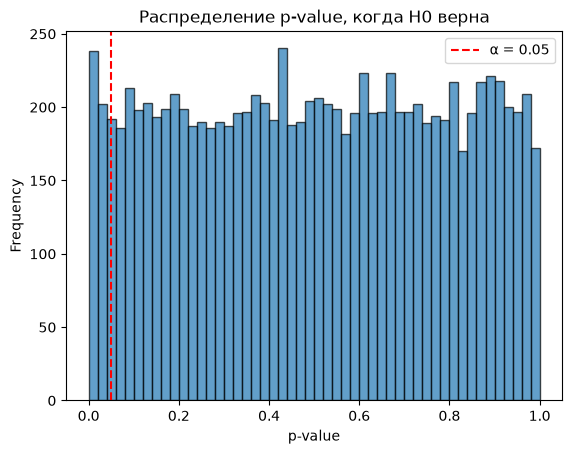

Доля ложноположительных результатов: 0.0542


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

np.random.seed(42)

p_values = []

for _ in range(10000):
    # Генерируем две группы из одного распределения (H0 верна)
    group_a = np.random.normal(loc=10, scale=2, size=100)
    group_b = np.random.normal(loc=10, scale=2, size=100)
    
    # Проводим t-test
    _, p_val = ttest_ind(group_a, group_b)
    p_values.append(p_val)

# Визуализация
plt.hist(p_values, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=0.05, color='red', linestyle='--', label='α = 0.05')
plt.xlabel('p-value')
plt.ylabel('Frequency')
plt.title('Распределение p-value, когда H0 верна')
plt.legend()
plt.show()

# Считаем долю тестов, где p-value ≤ 0.05
false_positives = np.mean(np.array(p_values) <= 0.05)
print(f"Доля ложноположительных результатов: {false_positives:.4f}")

In [7]:
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu

np.random.seed(42)

# Генерируем две группы из логнормального распределения (сильный правый скос)
# Обе группы имеют одинаковое среднее в логарифмическом масштабе, 
# но на оригинальной шкале средние будут отличаться из-за скоса
group1 = np.random.lognormal(mean=0, sigma=1, size=100)
group2 = np.random.lognormal(mean=0, sigma=1, size=100)

# t-test (неправильно, т.к. данные не нормальные)
t_stat, p_t = ttest_ind(group1, group2)
print(f"t-test p-value: {p_t:.4f}")

# Mann-Whitney U (правильно, т.к. не требует нормальности)
u_stat, p_u = mannwhitneyu(group1, group2)
print(f"Mann-Whitney U p-value: {p_u:.4f}")

t-test p-value: 0.1625
Mann-Whitney U p-value: 0.5181


In [8]:
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu

np.random.seed(42)

# Группа A: числа от 1 до 10
group_a = np.arange(1, 11)

# Группа B: те же числа, но сдвинутые на +0.1 (очень маленький эффект)
group_b = np.arange(1.1, 11.1)

# t-test (видит разницу, потому что учитывает величины)
_, p_t = ttest_ind(group_a, group_b)
print(f"t-test p-value: {p_t:.6f}")

# Mann-Whitney U (не видит разницы, потому что ранги почти совпадают)
_, p_u = mannwhitneyu(group_a, group_b)
print(f"Mann-Whitney U p-value: {p_u:.6f}")

t-test p-value: 0.941940
Mann-Whitney U p-value: 0.733730


Сгенерируй две группы данных (каждая по 50 наблюдений) из логнормального распределения (сильный правый скос).

Группа A: lognormal(mean=0, sigma=0.5)

Группа B: lognormal(mean=0.2, sigma=0.5) (эффект есть, но данные скошены)

Напиши скрипт, который:

Строит гистограммы обеих групп (можно на одном графике).

Проверяет нормальность (Shapiro-Wilk) для каждой группы.

Проверяет равенство дисперсий (Levene).

Автоматически выбирает тест (t-test / Welch / Mann-Whitney) по алгоритму, который мы обсуждали.

Выводит p-value и четкий вердикт (отвергаем H0 или нет).

Бонус (на подумать): Запусти этот скрипт 100 раз (симуляция) и посчитай, в скольких процентах случаев t-test vs Mann-Whitney U правильно отвергают H0 (где эффект есть). Это покажет тебе мощность каждого теста на скошенных данных.

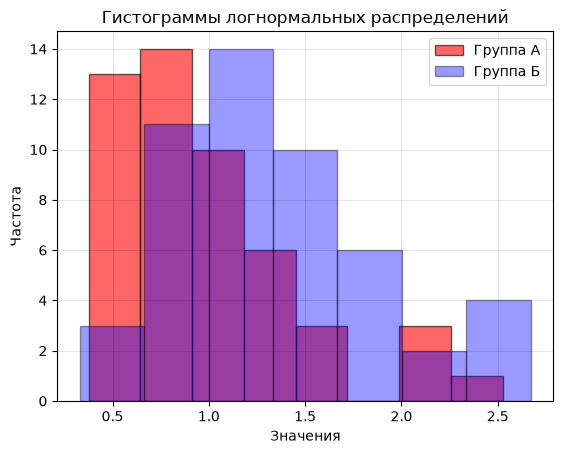

0.0002970876334127121  Отвергаем H0 для 1 выборки, данные не нормальны
0.03746630097465216  Отвергаем H0 для 2 выборки, данные не нормальны
0.2810488703112147
Не Отвергаем H0, дисперсии возможно равны
Использовали тест mannwhitneyu

p-value = 0.000574 < 0.05 → ОТВЕРГАЕМ H0
Вердикт: Различия между группами статистически значимы


In [74]:
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt
import scipy

np.random.seed(42)
grp1 = np.random.lognormal(mean=0,sigma=0.5,size=50)
grp2 = np.random.lognormal(mean=0.2, sigma=0.5,size=50)

plt.hist(grp1,bins = 'auto',edgecolor = 'black',alpha=.6,facecolor='red',label='Группа А')
plt.hist(grp2,bins = 'auto',edgecolor = 'black',alpha=.4,facecolor='blue',label='Группа Б')
plt.legend()
plt.grid(True,color = 'black',alpha = .1)
plt.title('Гистограммы логнормальных распределений')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.show()


statistic_1, p_value_1 = scipy.stats.shapiro(grp1)
statistic_2, p_value_2 = scipy.stats.shapiro(grp2)

if p_value_1 < 0.05:
    print(p_value_1,' Отвергаем H0 для 1 выборки, данные не нормальны')
if p_value_2 < 0.05:
    print(p_value_2, ' Отвергаем H0 для 2 выборки, данные не нормальны')

statistic_levene, p_value_levene = scipy.stats.levene(grp1,grp2)

print(p_value_levene)
if p_value_levene < 0.05:
    print('Отвергаем H0, дисперсии не равны')
else:
    print('Не Отвергаем H0, дисперсии возможно равны')


if p_value_1 < 0.05 or p_value_2 < 0.05:
    print('Использовали тест mannwhitneyu')
    _, p_value_test = mannwhitneyu(grp1,grp2)
elif p_value_levene >= 0.05:
    print('Использовали тест Стьюдента')
    _, p_value_test = ttest_ind(grp1,grp2,equal_var=True)
else:
    print('Использовали  Welchs t-test')
    _, p_value_test = ttest_ind(grp1,grp2,equal_var=False)


alpha = 0.05
if p_value_test < alpha:
    print(f"\np-value = {p_value_test:.6f} < {alpha} → ОТВЕРГАЕМ H0")
    print("Вердикт: Различия между группами статистически значимы")
else:
    print(f"p-value = {p_value_test:.6f} >= {alpha} → НЕ отвергаем H0")
    print("Вердикт: Статистически значимых различий не обнаружено")

In [ ]:
_, p_value_mwu = mannwhitneyu(grp1,grp2)
(p_value_mwu > 0.05)

np.int64(0)

In [76]:
def run_test(grp1, grp2, alpha=0.05):

    _, p_value_mwu = mannwhitneyu(grp1,grp2)

    _, p_value_test_St = ttest_ind(grp1,grp2,equal_var=True)

    _, p_value_test_W = ttest_ind(grp1,grp2,equal_var=False)

    return (p_value_mwu<alpha)*1,(p_value_test_St<alpha)*1,(p_value_test_W<alpha)*1

MWN,St,W = 0,0,0
for _ in range(100):
    grp1 = np.random.lognormal(mean=0,sigma=0.5,size=50)
    grp2 = np.random.lognormal(mean=0.3, sigma=0.5,size=50)

    mwn,st,w = run_test(grp1,grp2)
    MWN+=mwn
    St += st
    W += w

print(f'Манна Уитни = {MWN}%, Стьюдента = {St}%, Welchs = {W}%')


Манна Уитни = 83%, Стьюдента = 75%, Welchs = 75%


Напиши функцию calculate_power(effect_size, n, alpha=0.05, n_simulations=1000), которая:

Генерирует две группы из логнормального распределения с заданным эффектом (mean для группы B = effect_size).

Проводит Mann-Whitney U test 1000 раз.

Возвращает мощность (долю раз, когда p-value < alpha).

Запусти эту функцию для:

effect_size = 0.2, n = 50

effect_size = 0.5, n = 50

effect_size = 0.2, n = 200

Напиши вывод: "Чтобы получить мощность ≥ 80% при effect_size = 0.2, нужна выборка размером не менее X".

In [84]:
def calculate_power(effect_size, n, alpha=0.05, n_simulations=1000):

    sum_p = 0
    for _ in range(n_simulations):
        group_1 = np.random.lognormal(mean = 0,sigma = 0.5, size = n)
        group_2 = np.random.lognormal(mean = effect_size,sigma = 0.5, size = n)
        _, p_value_mwu = mannwhitneyu(group_1,group_2)
        sum_p += (p_value_mwu < alpha) * 1
    
    return sum_p/n_simulations * 100

In [90]:
# Сценарий 1
power_1 = calculate_power(effect_size=0.2, n=105)

# Сценарий 2  
power_2 = calculate_power(effect_size=0.5, n=50)

# Сценарий 3
power_3 = calculate_power(effect_size=0.2, n=200)

print(power_1,power_2,power_3)

80.0 99.9 97.5


r1 = 0.816
r2 = 0.816
r3 = 0.816
r4 = -0.100


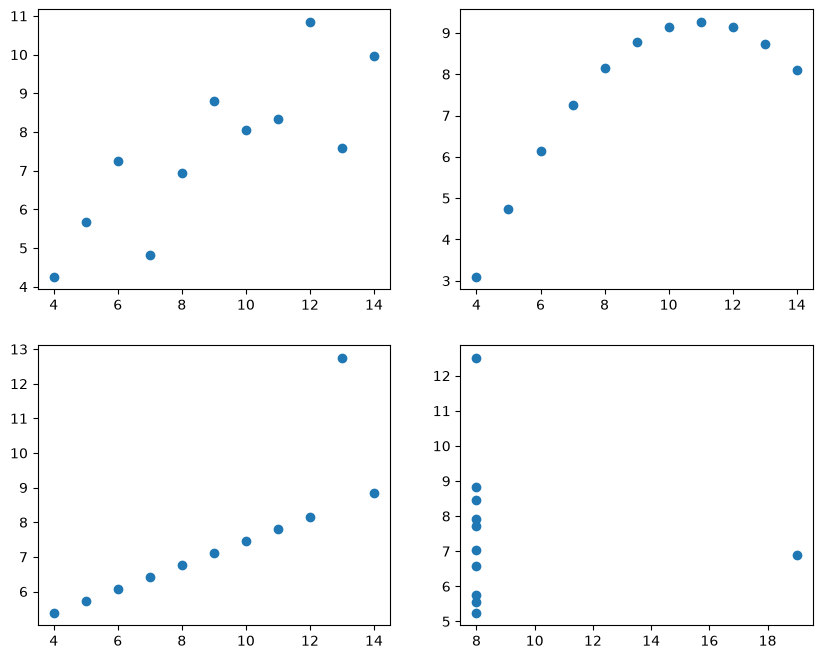

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Данные Анскомба (четыре набора с одинаковой корреляцией r ≈ 0.816)
x = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
y1 = [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]
y2 = [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]
y3 = [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]
x4 = [8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 19]
y4 = [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]

# Считаем корреляцию
print(f"r1 = {pearsonr(x, y1)[0]:.3f}")
print(f"r2 = {pearsonr(x, y2)[0]:.3f}")
print(f"r3 = {pearsonr(x, y3)[0]:.3f}")
print(f"r4 = {pearsonr(x4, y4)[0]:.3f}")

# Рисуем графики
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].scatter(x, y1)
axes[0, 1].scatter(x, y2)
axes[1, 0].scatter(x, y3)
axes[1, 1].scatter(x4, y4)
plt.show()

Корреляция на всех данных: r = 0.897
Корреляция в группе 'маленькие': r = 0.232
Корреляция в группе 'большие': r = 0.323


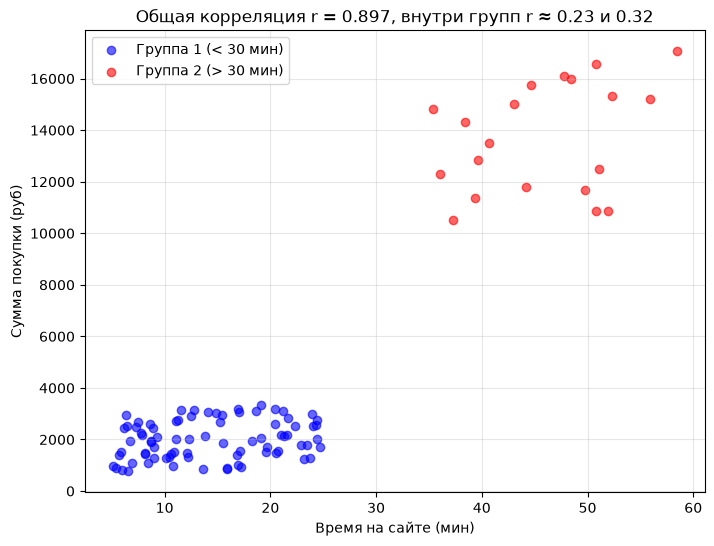

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

np.random.seed(42)

# Генерируем данные: две группы
# Группа 1: "маленькие" — время < 30 мин, сумма < 5000 руб
n1 = 80
time1 = np.random.uniform(5, 25, n1)
amount1 = np.random.uniform(500, 3000, n1) + time1 * 20  # слабая связь

# Группа 2: "большие" — время > 30 мин, сумма > 8000 руб
n2 = 20
time2 = np.random.uniform(35, 60, n2)
amount2 = np.random.uniform(8000, 15000, n2) + (time2 - 30) * 100  # сильная связь

# Объединяем
time_all = np.concatenate([time1, time2])
amount_all = np.concatenate([amount1, amount2])

# Корреляция на всех данных
r_all, _ = pearsonr(time_all, amount_all)
print(f"Корреляция на всех данных: r = {r_all:.3f}")

# Корреляция внутри групп
r1, _ = pearsonr(time1, amount1)
r2, _ = pearsonr(time2, amount2)
print(f"Корреляция в группе 'маленькие': r = {r1:.3f}")
print(f"Корреляция в группе 'большие': r = {r2:.3f}")

# Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(time1, amount1, color='blue', alpha=0.6, label='Группа 1 (< 30 мин)')
plt.scatter(time2, amount2, color='red', alpha=0.6, label='Группа 2 (> 30 мин)')
plt.xlabel('Время на сайте (мин)')
plt.ylabel('Сумма покупки (руб)')
plt.legend()
plt.title(f'Общая корреляция r = {r_all:.3f}, внутри групп r ≈ {r1:.2f} и {r2:.2f}')
plt.grid(True, alpha=0.3)
plt.show()

Корреляция Пирсона: 0.949
Корреляция Спирмена: 0.957


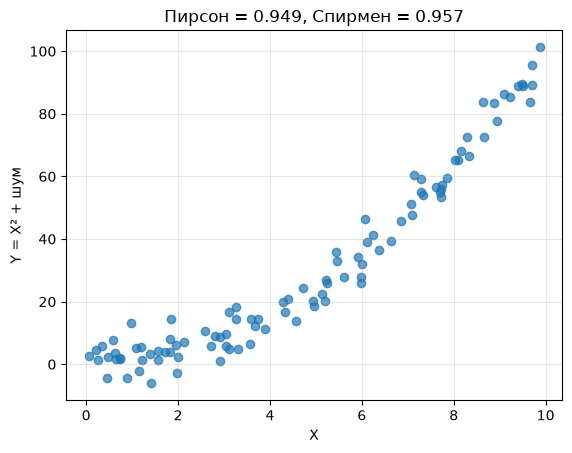

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

np.random.seed(42)

# Генерируем нелинейную зависимость: y = x^2 + шум
x = np.random.uniform(0, 10, 100)
y = x**2 + np.random.normal(0, 5, 100)

# Считаем корреляции
r_pearson, _ = pearsonr(x, y)
r_spearman, _ = spearmanr(x, y)

print(f"Корреляция Пирсона: {r_pearson:.3f}")
print(f"Корреляция Спирмена: {r_spearman:.3f}")

# Визуализация
plt.scatter(x, y, alpha=0.7)
plt.xlabel('X')
plt.ylabel('Y = X² + шум')
plt.title(f'Пирсон = {r_pearson:.3f}, Спирмен = {r_spearman:.3f}')
plt.grid(True, alpha=0.3)
plt.show()

In [97]:
import numpy as np
import statsmodels.api as sm

np.random.seed(42)

# Генерируем данные
age = np.random.normal(40, 10, 100)
experience = age * 0.8 + np.random.normal(0, 2, 100)  # сильно коррелирует с возрастом
salary = 30000 + age * 500 + experience * 300 + np.random.normal(0, 5000, 100)

# Модель 1: только возраст
X1 = sm.add_constant(age)
model1 = sm.OLS(salary, X1).fit()
print("Модель 1 (только возраст):")
print(f"Коэф. при возрасте: {model1.params[1]:.2f}")

# Модель 2: возраст + стаж (коррелирующие)
X2 = sm.add_constant(np.column_stack([age, experience]))
model2 = sm.OLS(salary, X2).fit()
print("\nМодель 2 (возраст + стаж):")
print(f"Коэф. при возрасте: {model2.params[1]:.2f}")
print(f"Коэф. при стаже: {model2.params[2]:.2f}")

Модель 1 (только возраст):
Коэф. при возрасте: 845.33

Модель 2 (возраст + стаж):
Коэф. при возрасте: 637.60
Коэф. при стаже: 269.31


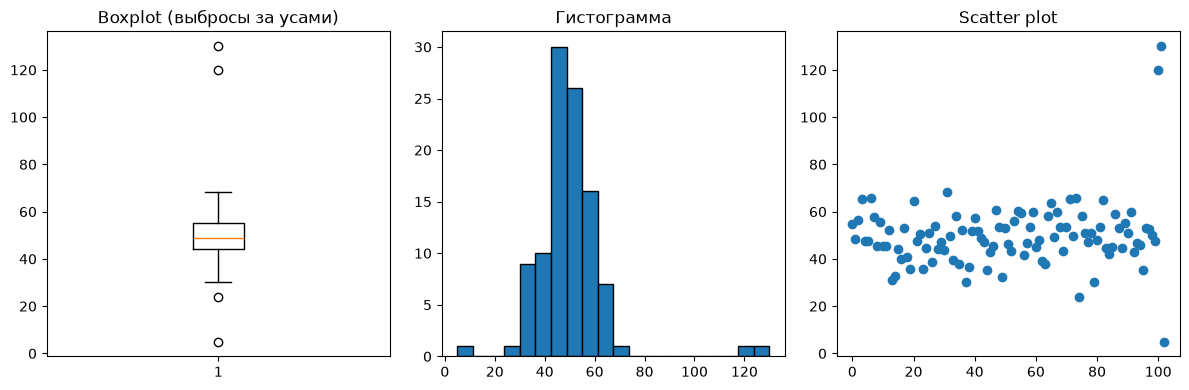

Выбросы по Z-score (>3): [100 101 102]
Выбросы по IQR: [ 74 100 101 102]
Всего выбросов по IQR: 4


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Генерируем данные: нормальное распределение + 3 выброса
data = np.random.normal(50, 10, 100)
outliers = np.array([120, 130, 5])  # искусственные выбросы
data = np.concatenate([data, outliers])

# 1. Z-score
z_scores = np.abs(stats.zscore(data))
z_outliers = np.where(z_scores > 3)[0]

# 2. IQR
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = np.where((data < lower_bound) | (data > upper_bound))[0]

# 3. Boxplot
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.boxplot(data)
plt.title('Boxplot (выбросы за усами)')
plt.subplot(1, 3, 2)
plt.hist(data, bins=20, edgecolor='black')
plt.title('Гистограмма')
plt.subplot(1, 3, 3)
plt.scatter(range(len(data)), data)
plt.title('Scatter plot')

plt.tight_layout()
plt.show()

print(f"Выбросы по Z-score (>3): {z_outliers}")
print(f"Выбросы по IQR: {iqr_outliers}")
print(f"Всего выбросов по IQR: {len(iqr_outliers)}")

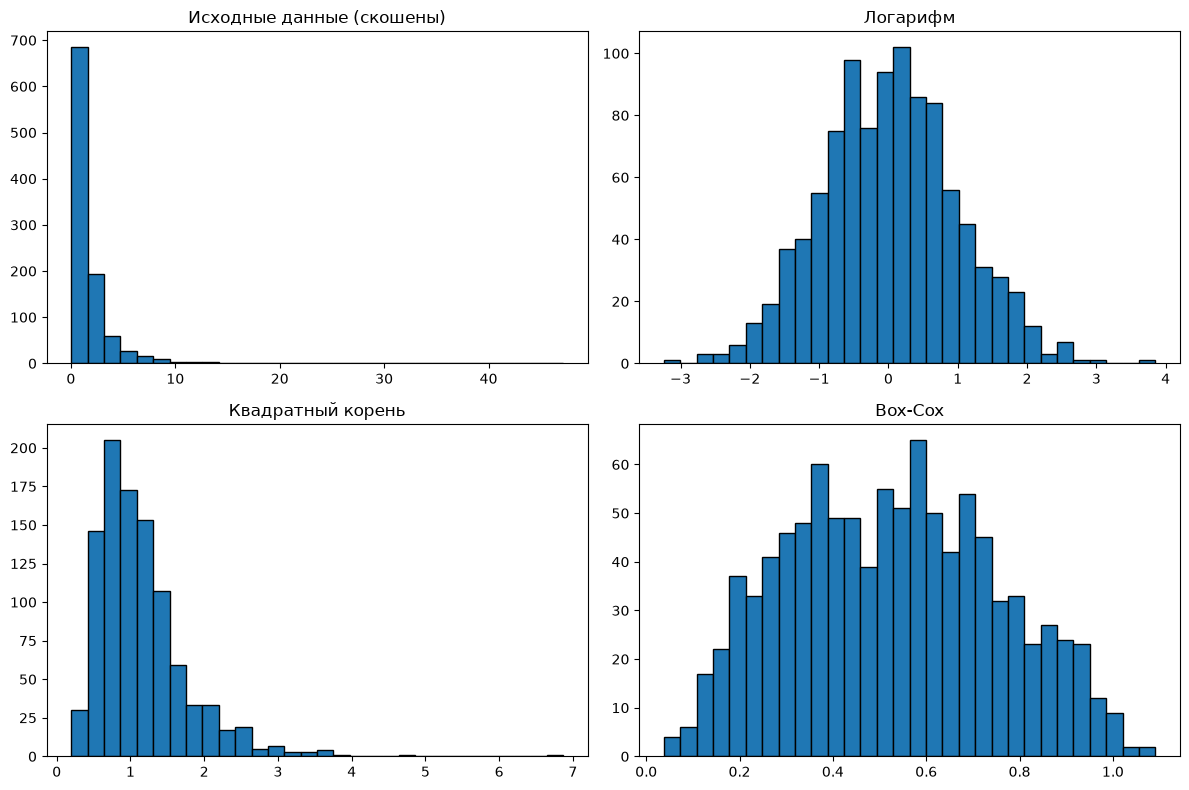

Исходные: skewness = 8.299
Логарифм: skewness = 0.117
Корень: skewness = 2.134
Box-Cox: skewness = 0.134


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox

np.random.seed(42)

# Генерируем логнормальные данные (сильный правый скос)
data = np.random.lognormal(mean=0, sigma=1, size=1000)

# Применяем преобразования
log_data = np.log(data)
sqrt_data = np.sqrt(data)
boxcox_data, _ = boxcox(data + 1)  # +1, чтобы избежать нулей

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(data, bins=30, edgecolor='black')
axes[0, 0].set_title('Исходные данные (скошены)')

axes[0, 1].hist(log_data, bins=30, edgecolor='black')
axes[0, 1].set_title('Логарифм')

axes[1, 0].hist(sqrt_data, bins=30, edgecolor='black')
axes[1, 0].set_title('Квадратный корень')

axes[1, 1].hist(boxcox_data, bins=30, edgecolor='black')
axes[1, 1].set_title('Box-Cox')

plt.tight_layout()
plt.show()

# Сравниваем скошенность (skewness)
print(f"Исходные: skewness = {stats.skew(data):.3f}")
print(f"Логарифм: skewness = {stats.skew(log_data):.3f}")
print(f"Корень: skewness = {stats.skew(sqrt_data):.3f}")
print(f"Box-Cox: skewness = {stats.skew(boxcox_data):.3f}")